In [1]:
"""
Try runing Qwen3 (0.6 B) and check its outputs format.
"""

'\nTry runing Qwen3 (0.6 B) and check its outputs format.\n'

In [2]:
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

c:\Users\yijin\anaconda3\envs\spec_decode\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model_name = "Qwen/Qwen3-0.6B"

# load the tokenizer and the model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,  # Qwen3 is bf16
    device_map="cuda"           
)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 311/311 [00:01<00:00, 189.15it/s]


In [ ]:
# check the model device
model.device

device(type='cuda', index=0)

In [5]:
# model input
prompt = "Give me a very short introduction to large language model."
messages = [
    {"role": "user", "content": prompt}
]

# apply tokenizer
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=True # switches between thinking and non-thinking modes. Default is True.
)

model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

In [6]:
model_inputs

{'input_ids': tensor([[151644,    872,    198,  35127,    752,    264,   1602,   2805,  16800,
            311,   3460,   4128,   1614,     13, 151645,    198, 151644,  77091,
            198]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]],
       device='cuda:0')}

In [ ]:
# generate process: conduct text completion
generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=32768,
    temperature=1,
    top_p=0.95,
    top_k=20,
    do_sample=True, # required when using temperature/top_p/top_k
    return_dict_in_generate=True, # returns a dict instead of raw ids
    output_scores=True, # includes per-step logits
)
sequences = generated_ids.sequences
# skip the input ids
output_ids = sequences[0][len(model_inputs.input_ids[0]):].tolist()

In [ ]:
# parsing thinking content
try:
    # rindex finding 151668 (id for the '</think>' token for qwen3_0.6B)
    # here we use len(output_ids) - output_ids[::-1].index(151668)
    # to catch the last </think> token
    index = len(output_ids) - output_ids[::-1].index(151668)
except ValueError:
    index = 0

thinking_content = tokenizer.decode(output_ids[:index])
content = tokenizer.decode(output_ids[index:])

print("thinking content:", thinking_content)
print("content:", content)

thinking content: <think>
Okay, the user wants a very short introduction to a large language model. Let me start by recalling the key points about LLMs. They are large-scale language models, like GPT or BERT, which use neural networks to understand and generate text. The main features include capability in complex tasks and multi-modal processing. I should mention their purpose, like language understanding, generating text, and use cases. Need to keep it concise, maybe two to three sentences. Avoid technical jargon. Check for clarity and make sure it's a good introduction without getting too detailed.
</think>
content: 

A large language model is a sophisticated AI system designed to understand and generate human language. They use deep learning to process and understand text, enabling tasks like conversation, text creation, and information retrieval.<|im_end|>


In [50]:
# check the prob for each generated tokens
scores = generated_ids.scores # this returns logits for each token
# convert logits to probabilities for each generated token
token_and_probs = []
all_probs = []
for i, (token_id, step_scores) in enumerate(zip(output_ids, scores)):
    probs = torch.softmax(step_scores[0], dim=-1)   # [vocab_size]
    token_prob = probs[token_id].item()
    token = tokenizer.decode([token_id])
    token_and_probs.append((token, token_prob))
    all_probs.append(token_prob)

In [48]:
# check the first 20 tokens
print(token_probs[:20])

[('<think>', 1.0), ('\n', 1.0), ('Okay', 1.0), (',', 1.0), (' the', 1.0), (' user', 1.0), (' wants', 0.7361247539520264), (' a', 1.0), (' very', 0.9399133324623108), (' short', 1.0), (' introduction', 1.0), (' to', 1.0), (' a', 0.9324532747268677), (' large', 1.0), (' language', 1.0), (' model', 1.0), ('.', 1.0), (' Let', 0.9241418242454529), (' me', 1.0), (' start', 1.0)]


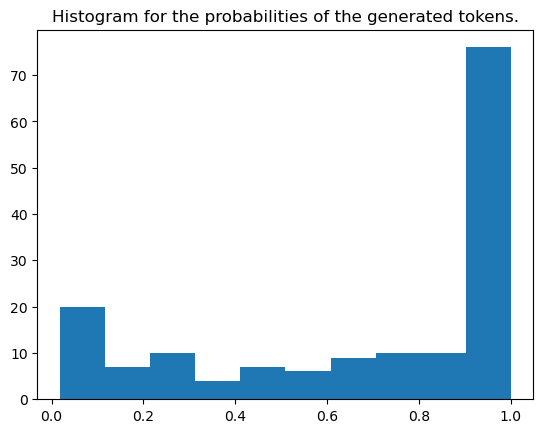

In [53]:
plt.hist(all_probs)
plt.title('Histogram for the probabilities of the generated tokens.')
plt.show()
